In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf

In [14]:
df = pd.read_csv(
    "..\data\processed\master_data.csv",
    index_col="timestamp",
    parse_dates=True
)

(8759, 9)
open            float64
high            float64
low             float64
close           float64
volume          float64
funding_rate    float64
fear_greed      float64
dxy             float64
nasdaq          float64
dtype: object


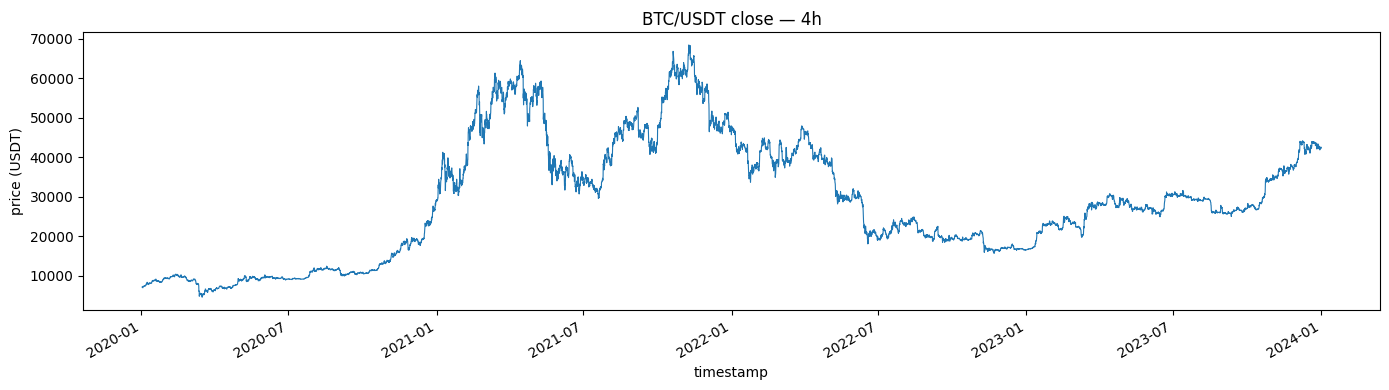

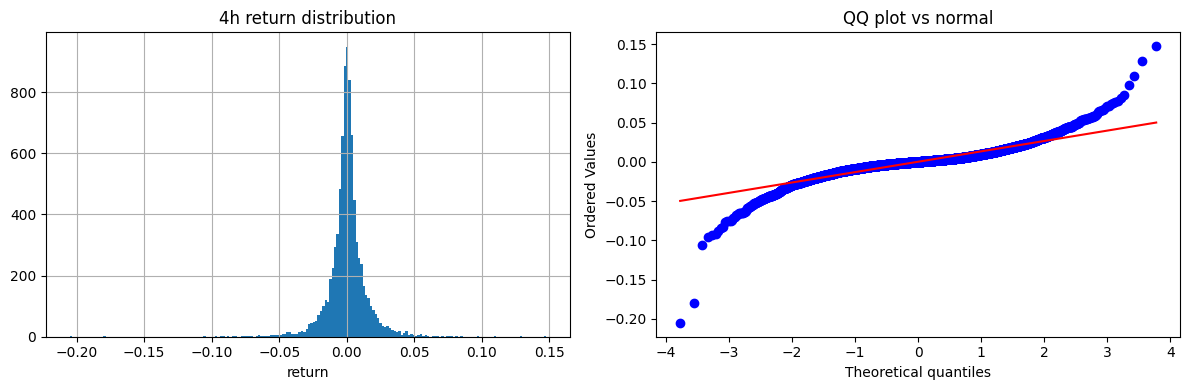

skew     : -0.4558
kurtosis : 15.7452


In [15]:
# === 1. shape & types ===
print(df.shape)
print(df.dtypes)

# === 2. price chart ===
fig, ax = plt.subplots(figsize=(14, 4))
df["close"].plot(ax=ax, linewidth=0.8)
ax.set_title("BTC/USDT close — 4h")
ax.set_ylabel("price (USDT)")
plt.tight_layout()
plt.show()

# === 3. return distribution ===
returns = df["close"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

returns.hist(bins=200, ax=axes[0])
axes[0].set_title("4h return distribution")
axes[0].set_xlabel("return")

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("QQ plot vs normal")

plt.tight_layout()
plt.show()

print(f"skew     : {returns.skew():.4f}")
print(f"kurtosis : {returns.kurtosis():.4f}")

In [16]:
# test on price
adf_price = adfuller(df["close"].dropna())
print(f"ADF price     — stat: {adf_price[0]:.4f}  p-value: {adf_price[1]:.4f}")

# test on log returns
log_returns = np.log(df["close"] / df["close"].shift(1)).dropna()
adf_returns = adfuller(log_returns)
print(f"ADF log ret   — stat: {adf_returns[0]:.4f}  p-value: {adf_returns[1]:.4f}")

# test on funding rate
adf_funding = adfuller(df["funding_rate"].dropna())
print(f"ADF funding   — stat: {adf_funding[0]:.4f}  p-value: {adf_funding[1]:.4f}")

ADF price     — stat: -1.7336  p-value: 0.4139
ADF log ret   — stat: -14.6396  p-value: 0.0000
ADF funding   — stat: -7.1909  p-value: 0.0000


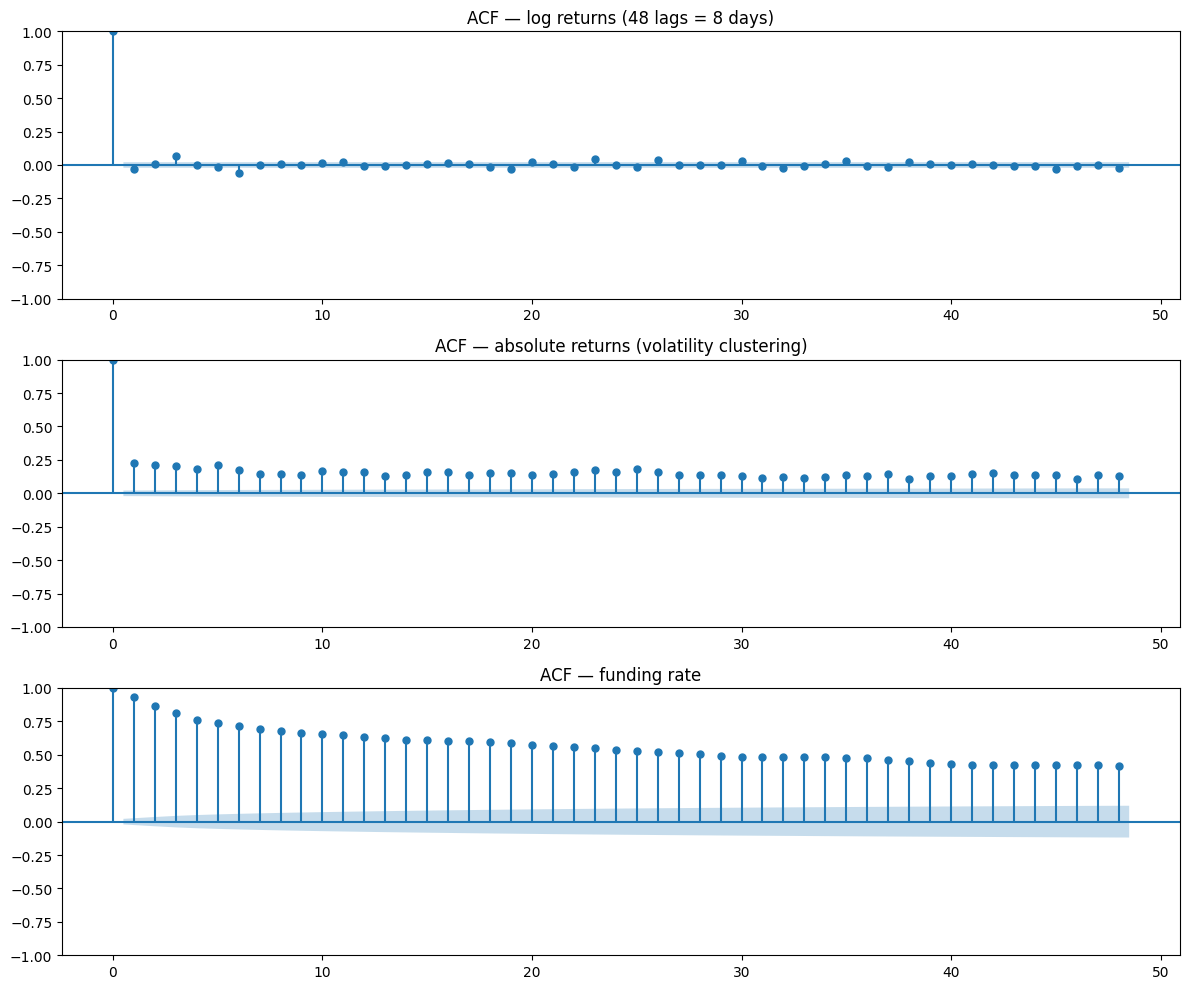

In [17]:
log_returns = np.log(df["close"] / df["close"].shift(1)).dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# returns autocorrelation
plot_acf(log_returns, lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — log returns (48 lags = 8 days)")

# absolute returns (volatility clustering)
plot_acf(log_returns.abs(), lags=48, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF — absolute returns (volatility clustering)")

# funding rate
plot_acf(df["funding_rate"].dropna(), lags=48, ax=axes[2], alpha=0.05)
axes[2].set_title("ACF — funding rate")

plt.tight_layout()
plt.show()

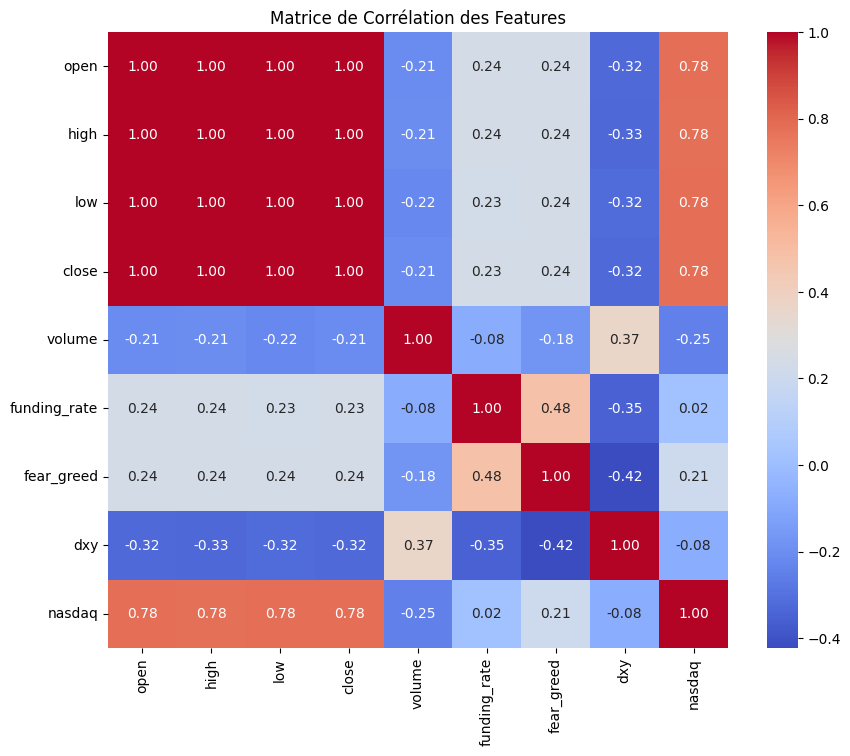

In [18]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des Features")
plt.show()

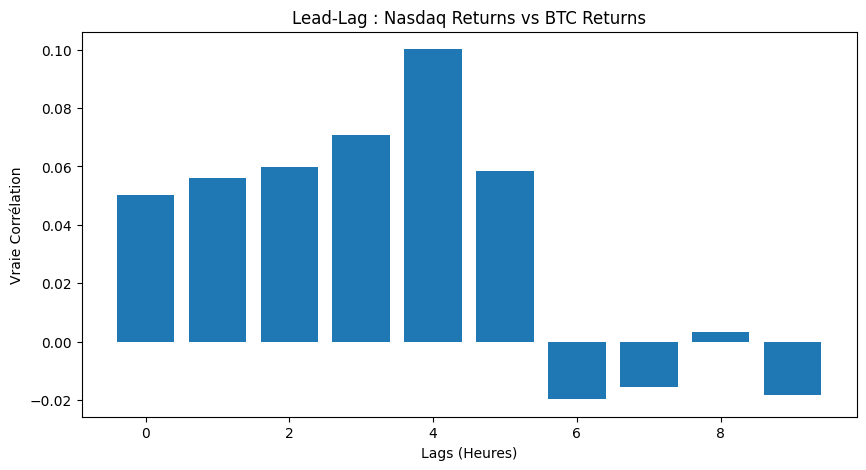

In [21]:
# 1. Calcul des rendements (on enlève le premier NaN avec .dropna())
returns_btc = np.log(df['close'] / df['close'].shift(1)).dropna()
returns_nasdaq = np.log(df['nasdaq'] / df['nasdaq'].shift(1)).dropna()

# 2. On aligne les deux séries (au cas où il y aurait des décalages)
common_index = returns_btc.index.intersection(returns_nasdaq.index)
ret_btc = returns_btc.loc[common_index]
ret_nasdaq = returns_nasdaq.loc[common_index]

# 3. Calcul de la Cross-Correlation
correlation_values = ccf(ret_btc, ret_nasdaq)[:10]

# 4. Plot
plt.figure(figsize=(10, 5))
plt.bar(range(10), correlation_values)
plt.title("Lead-Lag : Nasdaq Returns vs BTC Returns")
plt.xlabel("Lags (Heures)")
plt.ylabel("Vraie Corrélation")
plt.show()

In [20]:
# On utilise le log du prix pour la stabilité mathématique
series = np.log(df['close']).values 

lags = range(2, 20)
tau = [np.sqrt(np.std(np.subtract(series[lag:], series[:-lag]))) for lag in lags]
poly = np.polyfit(np.log(lags), np.log(tau), 1)

hurst_exp = poly[0] * 2
print(f"Hurst exponent: {hurst_exp:.4f}")

Hurst exponent: 0.5016


In [23]:
df['close_ret'] = np.log(df['close'] / df['close'].shift(1))
df['nasdaq_ret'] = np.log(df['nasdaq'] / df['nasdaq'].shift(1))
df['dxy_ret'] = np.log(df['dxy'] / df['dxy'].shift(1))

# On supprime la première ligne qui contient des NaN après le shift
df_clean = df.dropna().copy()

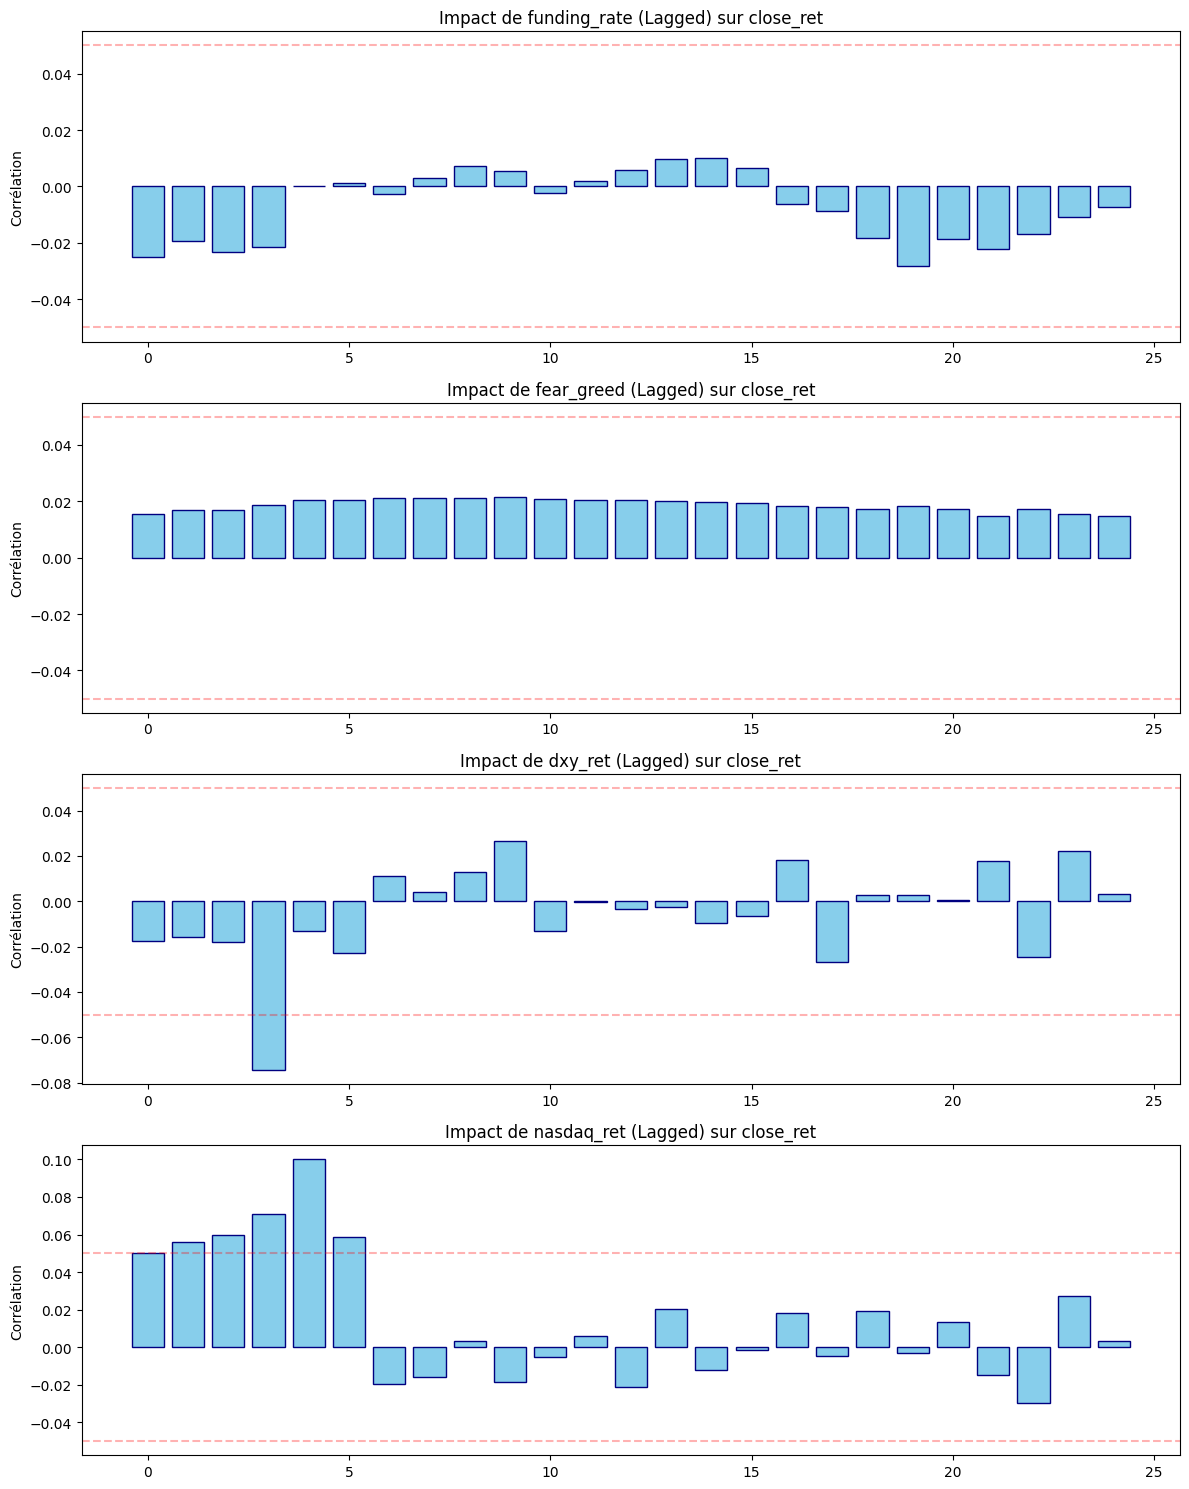

In [24]:
features_to_test = ['funding_rate', 'fear_greed', 'dxy_ret', 'nasdaq_ret']
target = 'close_ret'

fig, axes = plt.subplots(len(features_to_test), 1, figsize=(12, 15))

for i, feat in enumerate(features_to_test):
    # Calcul de la Cross-Correlation sur 24 heures (lags)
    # On regarde comment la feature influence le futur de 'close_ret'
    corr_vals = [df_clean[target].corr(df_clean[feat].shift(lag)) for lag in range(25)]
    
    axes[i].bar(range(25), corr_vals, color='skyblue', edgecolor='navy')
    axes[i].axhline(y=0.05, color='r', linestyle='--', alpha=0.3)
    axes[i].axhline(y=-0.05, color='r', linestyle='--', alpha=0.3)
    axes[i].set_title(f"Impact de {feat} (Lagged) sur {target}")
    axes[i].set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

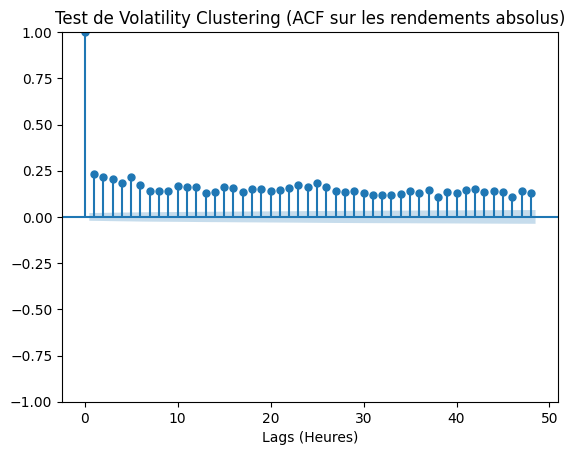

In [25]:
# On utilise la valeur absolue des rendements pour mesurer l'intensité du mouvement
abs_ret = df_clean['close_ret'].abs()

plt.figure(figsize=(12, 5))
plot_acf(abs_ret, lags=48, alpha=0.05)
plt.title("Test de Volatility Clustering (ACF sur les rendements absolus)")
plt.xlabel("Lags (Heures)")
plt.show()

In [26]:
# Calcul des statistiques de base
stats_df = pd.DataFrame(index=df_clean.columns)
stats_df['Skewness'] = df_clean.skew()
stats_df['Kurtosis'] = df_clean.kurtosis()

# Calcul des p-values du test ADF (Stationnarité)
p_values = []
for col in df_clean.columns:
    res = adfuller(df_clean[col])
    p_values.append(res[1])

stats_df['ADF_p-value'] = p_values
stats_df['Stationary'] = stats_df['ADF_p-value'] < 0.05

# On affiche uniquement tes 4 features + la target
cols_to_show = ['close_ret', 'funding_rate', 'fear_greed', 'dxy_ret', 'nasdaq_ret']
print("--- RÉSUMÉ STATISTIQUE DES FEATURES ---")
display(stats_df.loc[cols_to_show].sort_values('Kurtosis', ascending=False))

--- RÉSUMÉ STATISTIQUE DES FEATURES ---


,Skewness,Kurtosis,ADF_p-value,Stationary
nasdaq_ret,-1.281043,72.147204,0.000000e+00,True
dxy_ret,-0.368459,35.987888,0.000000e+00,True
funding_rate,2.768006,26.775961,2.509372e-10,True
close_ret,-0.864333,19.276280,3.642270e-27,True
fear_greed,0.229056,-0.910295,8.790933e-03,True
